In [78]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import xtrack as xt
import xpart as xp
import xcoll as xc

In [6]:
line = xt.load('../../..//injection_lines/sps_with_aperture_inj_q20_beam_sagitta4.json')

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           


In [8]:
num_particles  = 2000
plane = 'DPpos'
sweep = 6000
sweep = -abs(sweep) if plane == 'DPpos' else abs(sweep)
num_turns = 6000
nemitt_x = 2e-6
nemitt_y = 2e-6
sigma_z = 0.224

In [21]:
part.energy0

LinkedArrayCpu([2.59369766e+10, 2.59369766e+10, 2.59369766e+10, ...,
                2.59369766e+10, 2.59369766e+10, 2.59369766e+10],
               shape=(2000,))

In [71]:
part = xp.generate_matched_gaussian_bunch(nemitt_x=nemitt_x,
                                          nemitt_y=nemitt_y,
                                          sigma_z=sigma_z, num_particles=num_particles, line=line)

*** Maximum RMS bunch length 0.2333663781336932m.
... distance to target bunch length: -2.2228e-01
... distance to target bunch length: 4.5424e-03
... distance to target bunch length: 4.3382e-03
... distance to target bunch length: -6.6565e-03
... distance to target bunch length: 2.0203e-03
... distance to target bunch length: -5.7185e-04
... distance to target bunch length: 1.0779e-04
... distance to target bunch length: 4.7891e-06
... distance to target bunch length: -2.0504e-09
... distance to target bunch length: 9.6490e-08
--> Bunch length: 0.22399999794961267
--> Emittance: 0.3434772146538057


In [23]:
line.track(part, num_turns=10)

In [72]:
LM = xc.LossMap(line, part, interpolation=False)

In [73]:
LM.to_json('lossmap.json')

In [76]:
LM2 = xc.LossMap(line, part, interpolation=False)
LM2.from_json('lossmap.json')

ValueError: operands could not be broadcast together with shapes (5,) (0,) 

In [75]:
LM2.from_json('lossmap.json')

ValueError: operands could not be broadcast together with shapes (5,) (0,) 

# Trying normal plots

In [26]:
import sys

In [30]:
from pathlib import Path
import re
import json

In [28]:
path = Path('/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/LossLocationsCheck/LossLocationFiles/')
name_files = [p.name for p in path.iterdir()]

In [29]:
name_files

['linear_1.2_DPneg.json',
 'linear_-1.0_DPneg.json',
 'errors_0.1_DPneg.json',
 'errors_-0.3_DPneg.json',
 'linear_-0.4_DPpos.json',
 'linear_0.6_DPpos.json',
 'errors_1.5_DPpos.json',
 'linear_-0.8_DPneg.json',
 'linear_-0.9_DPpos.json',
 'errors_0.0_DPpos.json',
 'linear_-1.1_DPpos.json',
 'linear_1.3_DPpos.json',
 'errors_1.4_DPneg.json',
 'linear_0.7_DPneg.json',
 'linear_-0.5_DPneg.json',
 'errors_-0.2_DPpos.json',
 'errors_0.9_DPneg.json',
 'errors_1.1_DPneg.json',
 'errors_-0.7_DPpos.json',
 'linear_0.2_DPneg.json',
 'errors_0.5_DPpos.json',
 'linear_-1.4_DPpos.json',
 'errors_-1.3_DPneg.json',
 'linear_0.3_DPpos.json',
 'errors_-0.6_DPneg.json',
 'linear_-0.1_DPpos.json',
 'errors_1.0_DPpos.json',
 'errors_-1.2_DPpos.json',
 'linear_-1.5_DPneg.json',
 'errors_0.4_DPneg.json',
 'errors_0.8_DPpos.json',
 'linear_0.8_DPneg.json',
 'linear_1.0_DPneg.json',
 'errors_-1.5_DPpos.json',
 'linear_-1.2_DPneg.json',
 'errors_0.3_DPneg.json',
 'errors_-0.1_DPneg.json',
 'linear_-0.6_DPpos.

In [57]:
loss_locations = {'linear' : {}, 'errors' : {}}
line = xt.load('../../..//injection_lines/sps_with_aperture_inj_q20_beam_sagitta4.json')
tt = line.get_table()
pattern = re.compile(r"^(?P<line_type>.+)_(?P<chroma>[^_]+)_(?P<plane>[^_]+)\.json$")
for name in name_files:
    match = pattern.match(name)
    if match is None:
        print(f"File {name} does not match the expected pattern. Skipping.")
        continue
    line_type = match.group('line_type')
    chroma = float(match.group('chroma'))
    plane = match.group('plane')
    print(f"Processing file: {name} with line_type: {line_type}, chroma: {chroma}, plane: {plane}")
    
    if chroma not in loss_locations[line_type]:
        loss_locations[line_type][chroma] = {}
    if plane not in loss_locations[line_type][chroma]:
        loss_locations[line_type][chroma][plane] = {'s' : [], 'n' : [], 'name' : []}
    with open(path / name, 'r') as f:
        data = json.load(f)
    apers = list(data.keys())
    losses = list(data.values())
    if "sps$start" in apers:
        losses.pop(apers.index("sps$start"))
        apers.remove("sps$start")
    s_positions = tt.rows[apers].s

    loss_locations[line_type][chroma][plane]['s'] = s_positions
    loss_locations[line_type][chroma][plane]['n'] = np.array(losses)
    loss_locations[line_type][chroma][plane]['name'] = np.array(apers)
    

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
Processing file: linear_1.2_DPneg.json with line_type: linear, chroma: 1.2, plane: DPneg
Processing file: linear_-1.0_DPneg.json with line_type: linear, chroma: -1.0, plane: DPneg
Processing file: errors_0.1_DPneg.json with line_type: errors, chroma: 0.1, plane: DPneg
Processing file: errors_-0.3_DPneg.json with line_type: errors, chroma: -0.3, plane: DPneg
Processing file: linear_-0.4_DPpos.json with line_type: linear, chroma: -0.4, plane: DPpos
Processing file: linear_0.6_DPpos.json with line_type: linear, chroma: 0.6, plane: DPpos
Processing file: errors_1.5_DPpos.json with line_type: errors, chroma: 1.5, plane: DPpos
Processing file: linear_-0.8_DPneg.json with line_type: linear, chroma: -0.8, plane: DPneg
Processing file: linear_-0.9_DPpos.json with line_type: linear, chroma: -0.9, plane: DPpos
Processing file: errors_0.0_DPpos.json with line_type: errors, chroma: 0.0, plane: DPpos
Processing file: linear_-1.1_DPpos.json with line_type: line

In [58]:
loss_locations

{'linear': {1.2: {'DPneg': {'s': array([  29.8516,  797.7962, 1949.1635, 3098.5008, 3482.4735, 4250.4181,
           5402.3354, 5786.3081, 6202.278 , 6203.6985, 6554.2527]),
    'n': array([ 30,  10,  10,  22, 169,  14, 475,  45,  43, 174,   5]),
    'name': array(['vcak.10101.a_aper', 'vcak.12501.a_aper', 'vcak.22501.a_aper',
           'vcak.32501.a_aper', 'vcak.40101.a_aper', 'vcak.42501.a_aper',
           'vcak.52501.a_aper', 'vcak.60101.a_aper', 'vttw.61402.a_aper',
           'vttw.61402.b_aper', 'vcak.62501.a_aper'], dtype='<U17')},
   'DPpos': {'s': array([1501.1956, 2653.1129, 3802.4503, 4954.3676, 6106.2849]),
    'n': array([369,  38,  28,  33, 528]),
    'name': array(['vcak.21101.a_aper', 'vtto.31105.a_aper', 'vcak.41101.a_aper',
           'vcak.51101.a_aper', 'vcak.61101.a_aper'], dtype='<U17')}},
  -1.0: {'DPneg': {'s': array([ 797.7962, 1949.1635, 3098.5008, 4250.4181, 5402.3354, 6106.2849,
           6554.2527]),
    'n': array([ 91,  94, 137,  26, 646,   1,   4]),
 

In [59]:
len(s)

11

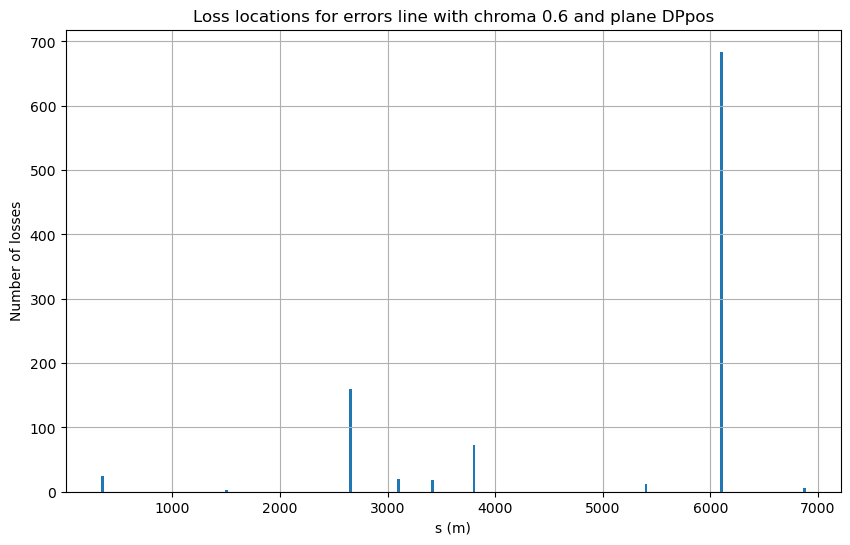

In [70]:
fig, ax = plt.subplots(figsize=(10, 6))
s = loss_locations[lt][chroma][plane]['s']
n = loss_locations[lt][chroma][plane]['n']
name = loss_locations[lt][chroma][plane]['name']
ax.bar(s, n, width=25)
ax.set_xlabel('s (m)')
ax.set_ylabel('Number of losses')
ax.set_title(f'Loss locations for {lt} line with chroma {chroma} and plane {plane}')
ax.grid()
plt.show()

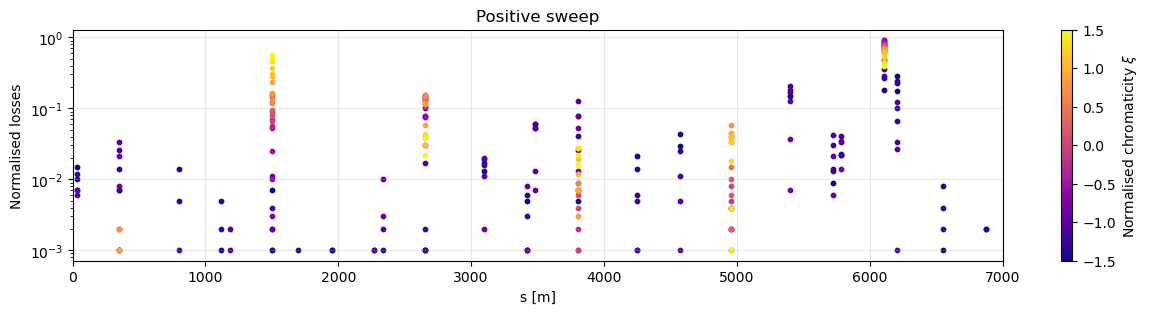

In [116]:
cmap = colormaps['plasma']
norm = plt.Normalize(vmin=-1.5, vmax=1.5)
lt = 'linear'
plane = 'DPpos'
chromas = sorted(loss_locations[lt].keys())
fig, ax = plt.subplots(figsize=(15, 3))
for chroma in chromas:
    s = loss_locations[lt][chroma][plane]['s']
    n = loss_locations[lt][chroma][plane]['n']
    name = loss_locations[lt][chroma][plane]['name']
    color = cmap(norm(chroma))
    ax.scatter(s, n/1000, color=color, s=10)

ax.set_yscale('log')
ax.set_xlabel('s [m]')
ax.set_ylabel('Normalised losses')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r'Normalised chromaticity $\xi$')
ax.grid(alpha=0.3)
ax.set_title('Positive sweep')
ax.set_xlim(0, 7000)
plt.show()

In [149]:
loss_locations[lt][1.5]['DPpos']['name'][loss_locations[lt][1.5]['DPpos']['n']/1000 >0.1], loss_locations[lt][1.5]['DPpos']['n'][loss_locations[lt][1.5]['DPpos']['n']/1000 >0.1]

(array(['vcak.21101.a_aper', 'vcak.61101.a_aper'], dtype='<U17'),
 array([560, 398]))

In [ ]:
loss_locations[lt][-1.0]['DPpos']['n']/1000 >0.1

array([False, False,  True, False,  True, False, False])

In [121]:
tt = line.get_table()

In [145]:
tt.rows['qd.40110']

Table: 1 row, 11 cols
name                 s element_type isthick isreplica parent_name iscollective       s_start ...
qd.40110       3484.62 Quadrupole      True     False None               False       3484.62

In [124]:
tt.rows['vttw.61402.a_aper<<10':'vttw.61402.a_aper>>10']

Table: 21 rows, 11 cols
name                             s element_type            isthick isreplica parent_name ...
mba.61390..8_aper2         6200.82 LimitRect                 False     False None       
mba.61390..8               6200.82 ThickSliceRBend            True     False mba.61390  
mba.61390..9_aper2         6201.45 LimitRect                 False     False None       
mba.61390..9               6201.45 ThickSliceRBend            True     False mba.61390  
mba.61390..10_aper2        6202.07 LimitRect                 False     False None       
mba.61390..exit_map        6202.07 ThinSliceRBendExit        False     False mba.61390  
mba.61390_exit             6202.07 Marker                    False     False None       
drift_1699..0              6202.07 DriftSlice                 True     False drift_1699 
veba.61390.b_aper          6202.28 LimitRect                 False     False None       
drift_1699..1              6202.28 DriftSlice                 True     False drift

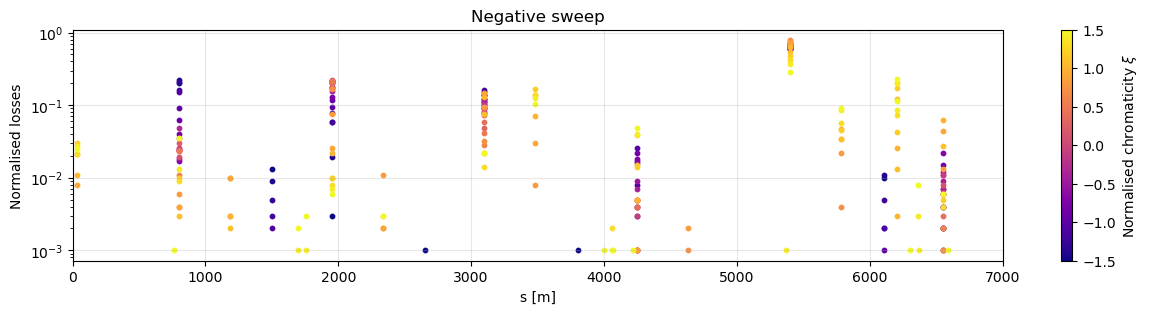

In [117]:
cmap = colormaps['plasma']
norm = plt.Normalize(vmin=-1.5, vmax=1.5)
lt = 'linear'
plane = 'DPneg'
chromas = sorted(loss_locations[lt].keys())
fig, ax = plt.subplots(figsize=(15, 3))
for chroma in chromas:
    s = loss_locations[lt][chroma][plane]['s']
    n = loss_locations[lt][chroma][plane]['n']
    name = loss_locations[lt][chroma][plane]['name']
    color = cmap(norm(chroma))
    ax.scatter(s, n/1000, color=color, s=10)
    # ax.bar(s, n/1000, width=25, color=color)

ax.set_yscale('log')
ax.set_xlabel('s [m]')
ax.set_ylabel('Normalised losses')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r'Normalised chromaticity $\xi$')
ax.grid(alpha=0.3)
ax.set_title('Negative sweep')
ax.set_xlim(0, 7000)
plt.show()

In [96]:
LM = xc.LossMap(line, part, interpolation=False)
LM.from_json('lossmap.json')

<LossMap (997 losses on aperture and 0 losses on collimators - 1000 initial protons at 2.592e+10 eV/c) at 0x307c9efd0>

In [94]:
LM.plot()

ValueError: Empty loss map.